##### 실행 환경 설정

In [22]:
try:
    # Google Drive를 Colab에 마운트
    from google.colab import drive
    drive.mount('/google_drive')

    # 작업 경로 설정
    WORK_DIR = "/google_drive/Othercomputers/내 Mac/sec09"
    print("\n[작업 폴더 목록]")
    %cd {WORK_DIR}
    !ls
    print()

    # 한글 폰트 설치
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm
    !apt-get -qq install fonts-nanum
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
except Exception:
    # 한글 폰트 설정
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'Malgun Gothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False

##### Device 설정

In [23]:
import torch

# GPU(CUDA) 사용 가능 시 'cuda', 아니면 'cpu' 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

사용 장치: cpu


##### 재현성 설정

In [24]:
import numpy as np
import random

# 재현성 설정 - 같은 코드를 실행했을 때 항상 동일한 결과가 나오는 랜덤 SEED 설정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

##### 학습 데이터셋 로드

In [25]:
import pandas as pd

# NSMC 원본 TSV 파일을 GitHub에서 직접 로드
# - 컬럼: id, document(리뷰 텍스트), label(0=부정, 1=긍정)
train_df = pd.read_csv(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt",
    sep='\t'
)

print(f"학습 샘플 수: {len(train_df)}")
train_df.head()

학습 샘플 수: 150000


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


##### 검증 데이터셋 로드

In [26]:
val_df = pd.read_csv(
    "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt",
    sep='\t'
)

print(f"검증 샘플 수: {len(val_df)}")
val_df.head()

검증 샘플 수: 50000


,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0


##### 빈 리뷰 제거

In [27]:
# 빈 리뷰(NaN) 제거
# - NSMC 원본 파일에 실제로 빈 리뷰 행이 몇 건 있어서 처리가 필요
# - document 컬럼에 NaN이 있는 행을 제거하고 인덱스 재설정
train_df = train_df.dropna(subset=['document']).reset_index(drop=True)
val_df  = val_df.dropna(subset=['document']).reset_index(drop=True)

print(f"학습 샘플 수: {len(train_df)}")
print(f"검증 샘플 수: {len(val_df)}")

학습 샘플 수: 149995
검증 샘플 수: 49997


##### HuggingFace의 Dataset과 DatasetDict 타입으로 변환:

In [28]:
# Datasets 모듈:
# - HuggingFace의 Datasets 라이브러리를 사용하면
#   데이터 전처리, 토크나이징, 배치 처리 등을 효율적으로 수행할 수 있음
# - Dataset: 개별 데이터셋 (예: 학습, 검증, 테스트)
# - DatasetDict: 여러 데이터셋을 딕셔너리 형태로 묶어서 관리
#   (예: {'train': train_dataset, 'val': val_dataset})
# - torch.utils.data.Dataset과 이름 충돌 방지를 위해 HFDataset으로 alias 처리
from datasets import Dataset as HFDataset, DatasetDict

# HuggingFace Dataset 형식으로 변환
datasetDict = DatasetDict({
    'train': HFDataset.from_pandas(train_df),
    'val':  HFDataset.from_pandas(val_df),
})

# 데이터셋 정보 출력
print(f"학습 데이터 크기: {len(datasetDict['train'])}")
print(f"검증 데이터 크기: {len(datasetDict['val'])}", "\n")

학습 데이터 크기: 149995
검증 데이터 크기: 49997 



##### 빠른 학습을 위해 데이터셋 축소

In [29]:
# collections 모듈
# - Python 표준 라이브러리의 일부로, 컨테이너 데이터 타입을 확장하여 제공하는 모듈
# - Counter 클래스:
#   - 값의 종류별로 개수를 세어 딕셔너리 형태로 반환하는 클래스
from collections import Counter

# 빠른 학습을 위해 데이터 일부만 사용
TRAIN_SIZE = 30000
VAL_SIZE = 1000
train_data = datasetDict['train'].shuffle(seed=SEED).select(range(TRAIN_SIZE))
val_data = datasetDict['val'].shuffle(seed=SEED).select(range(VAL_SIZE))
print(f"학습 데이터: {len(train_data)}건")
print(f"검증 데이터: {len(val_data)}건")

# 레이블 분포 확인
train_labels_counter = Counter(train_data['label'])

# 부정(0), 긍정(1) 샘플이 50:50으로 균형 잡혀 있음
print(f"\n학습 레이블 분포: 부정={train_labels_counter[0]}, 긍정={train_labels_counter[1]}")

학습 데이터: 30000건
검증 데이터: 1000건

학습 레이블 분포: 부정=15075, 긍정=14925


##### PyTorch Dataset 클래스 정의

In [30]:
# torch.utils.data.Dataset:
# - PyTorch에서 데이터셋을 표현하는 베이스 클래스
from torch.utils.data import Dataset

# NSMCDataset 클래스 정의
# - HuggingFace의 datasetDict는 딕셔너리 형태의 데이터 저장소일 뿐임
# - PyTorch 모델 학습을 위해서는 torch.utils.data.Dataset을 상속해서 자식 클래스를 만들어야 함
# - __len__과 __getitem__을 구현하지 않으면 호출 시 NotImplementedError 발생
class NSMCDataset(Dataset):
    # 초기화 메서드: 데이터, 토크나이저, 최대 길이를 입력으로 받아 저장
    # - data: HuggingFace Dataset 형식의 데이터셋 (예: train_data, val_data)
    # - tokenizer: HuggingFace의 AutoTokenizer로, 텍스트를 토큰화하는 역할
    # - max_length: 입력 문장의 최대 토큰 수 (초과 시 잘라내기, 부족 시 패딩)
    def __init__(self, data, tokenizer, max_length=128):
        self.samples = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    # __len__ 메서드: 데이터셋의 샘플 수 반환
    def __len__(self):
        return len(self.samples)

    # __getitem__ 메서드: 인덱스에 해당하는 샘플을 반환
    def __getitem__(self, idx):
        item = self.samples[idx]
        text = item['document']
        label = item['label']

        # 토크나이저로 텍스트를 토큰화하여 input_ids, attention_mask, token_type_ids 생성
        inputs = self.tokenizer(
            # 입력 문장
            text,
            # 한 문장의 최대 토큰 수 설정
            max_length=self.max_length,
            # 패딩 방식 설정
            # - False / 'do_not_pad': 패딩 없음
            # - True / 'longest': 배치 내 최장 시퀀스 기준
            # - 'max_length': max_length 값까지 패딩
            # - __getitem__에서는 배치 단위 처리가 아니므로 padding='max_length'로 고정하는게 맞음
            padding='max_length',
            # 한 문장의 토큰 수가 최대 토큰 수를 초과하면 잘라내기
            truncation=True,
            # PyTorch 텐서로 반환
            return_tensors='pt',
        )

        # 딕셔너리로 반환
        # 토크나이저가 반환하는 input_ids, attention_mask, token_type_ids는 모두 (1, max_length) 형태의
        # 2D 텐서이므로 squeeze()로 차원 축소하여 (max_length,) 형태로 변환해서 반환
        return {
            'input_ids': inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze(),
            'token_type_ids': inputs['token_type_ids'].squeeze(),
            'label': torch.tensor(label, dtype=torch.long),
        }


##### PyTorch DataLoader 생성

In [31]:
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

# 토크나이저 로드
model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Dataset 객체 생성
train_dataset = NSMCDataset(train_data, tokenizer, max_length=128)
val_dataset = NSMCDataset(val_data, tokenizer, max_length=128)

# DataLoader 생성
# - DataLoader는 Dataset에서 샘플을 배치 단위로 로드하는 유틸리티 클래스
# - batch_size: 학습시에는 메모리 사용량이 증가하므로 검증보다는 작은 값으로 설정하는 것이 일반적임
# - shuffle=True: 매 epoch마다 데이터 순서를 섞어서 모델이 데이터 순서에 의존하지 않도록 함
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# len(): __len__ 메서드를 구현한 객체의 길이를 반환하는 내장 함수
print(f"학습 배치 수: {len(train_loader)}")
print(f"검증 배치 수: {len(val_loader)}")

# 데이터 확인
# - DataLoader는 iterable 객체
# - iterable 객체: __iter__()를 구현한 객체, for문으로 반복 가능
# - iterator 객체: __iter__, __next__()를 구현한 객체
# - iter(): iterable -> iterator 변환 함수
# - next(): iterator에서 다음 요소를 반환하는 함수
sample_batch = next(iter(train_loader))
print(f"\n배치 input_ids 크기: {sample_batch['input_ids'].shape}")
print(f"배치 label 크기:     {sample_batch['label'].shape}")


학습 배치 수: 938
검증 배치 수: 16

배치 input_ids 크기: torch.Size([32, 128])
배치 label 크기:     torch.Size([32])


##### BERT 모델을 분류 헤드와 함께 로드

In [32]:
# transformers 모듈:
# - HuggingFace의 다양한 사전 학습된 언어 모델과 토크나이저를 제공하는 라이브러리
# AutoModelForSequenceClassification:
# - 사전 학습된 언어 모델(BERT 등) 위에 분류 헤드를 얹은 모델 클래스
from transformers import AutoModelForSequenceClassification

# KLUE BERT 모델을 분류 헤드와 함께 로드
model_name = "klue/bert-base"
model = AutoModelForSequenceClassification.from_pretrained(
    # 모델 이름
    model_name,
    # 부정(0), 긍정(1)
    num_labels=2,
    # 분류 헤드 드롭아웃 확률, 과적합 방지,
    # - 기본 값은 0.1, BERT 논문에서는 0.1 권장
    # - 실험적으로 0.3이 더 나은 성능을 보이는 경우도 있음
    classifier_dropout=0.3,
)

# 모델을 학습에 사용할 디바이스로 이동
model = model.to(device)

# 분류 헤드 확인
print("분류 헤드:")
print(model.classifier)

# 모델 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
print(f"\n전체 파라미터 수:     {total_params:,}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on you

분류 헤드:
Linear(in_features=768, out_features=2, bias=True)

전체 파라미터 수:     110,618,882


##### 옵티마이저와 스케쥴러 생성

In [33]:
# AdamW 옵티마이저 = Adam + Weight Decay(가중치 감쇠)
# - Adam:
#   - 과거 그래디언트의 평균 방향/크기를 기억하고 일관된 방향으로 빠르게 이동(모멘텀)
# - Weight Decay(가중치 감쇠)
#   - 과적합을 막기 위해 모델의 가중치를 0 방향으로 조금씩 당기는 규제 기법
#   - 원래 가중치 업데이트 수식: new_w = old_w - lr * dw
#   - 가중치 감쇠가 적용된 수식: wd_w = new_w * (1 - lr * weight_decay)
#   - 일반적으로 0.01 권장
# - model.parameters(): 모델의 모든 파라미터를 반환하는 메서드
# - lr: BERT 파인튜닝 학습률, 2e-5 ~ 5e-5 권장
# - weight_decay: 가중치 감쇠 계수, 일반적으로 0.01 권장
from torch.optim import AdamW
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# 사전 학습이 되어 있어서 적은 학습 에포크로도 빠르게 수렴.
# - 일반적으로 3~5 에포크 권장
# - Early Stopping을 사용하므로 최대 에포크를 넉넉히 설정하여 충분한 학습 기회 제공
# - 실제로는 Early Stopping에 의해 조기 종료될 가능성이 높음
NUM_EPOCHS = 10

# 총 학습 스텝 계산: 배치 수 * 에포크 수
train_steps = len(train_loader) * NUM_EPOCHS

# 학습 초반에 학습률을 0에서 목표값까지 서서히 올리는 웜업 적용
# 전체 학습 스텝의 10% 정도를 웜업 구간으로 할당하는 것을 권장
warmup_steps = int(train_steps * 0.1)

# 스케쥴러 생성
# 학습 초반에 웜업 구간에서는 학습률을 목표값까지 서서히 올려 안정적인 학습을 도모
# 웜업이 끝난 후에는 학습률이 선형적으로 감소하도록 설정
from transformers import get_linear_schedule_with_warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_training_steps=train_steps,
    num_warmup_steps=warmup_steps,
)

print(f"총 학습 스텝: {train_steps}")
print(f"웜업 스텝: {warmup_steps}")

총 학습 스텝: 9380
웜업 스텝: 938


##### 학습 함수 정의

In [34]:
def train_epoch(model, loader, optimizer, scheduler, device):
    # 모델을 학습 모드로 설정
    model.train()

    # 에포크 동안 처리한 총 샘플 수를 누적하는 변수
    epoch_sample_sum = 0
    # 에포크 동안 예측이 맞은 샘플 수를 누적하는 변수
    epoch_correct_sum = 0
    # 에포크 동안의 배치 손실을 누적하는 변수
    epoch_loss = 0

    # 에포크 동안 모든 배치를 반복
    for batch in loader:
        # 토큰 ID, 어텐션 마스크, 문장 구분 ID, 레이블을 디바이스로 이동
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        labels = batch['label'].to(device)
        # 옵티마이저 초기화: 그래디언트 누적 방지
        optimizer.zero_grad()
        # 모델에 입력하여 출력 얻기
        batch_outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels,  # labels는 훈련/검증시에 만 사용, 추론 시에는 필요 없음
        )
        # 그래디언트 계산
        batch_outputs.loss.backward()
        # 그래디언트 클리핑(값이 너무 커지는 것을 방지하여 학습 안정성 향상)
        # - 그래디언트가 1.0보다 크면 모든 그래디언트를 1.0 이하로 스케일링하여 폭주 방지
        # - BERT는 대형 모델이므로 그래디언트 폭주가 발생할 수 있어 클리핑이 중요
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # 파라미터 업데이트
        optimizer.step()
        # 학습률 스케줄러 업데이트
        scheduler.step()
        # 배치 손실 텐서를 스칼라 값으로 변환하고 에포크 손실에 누적
        epoch_loss += batch_outputs.loss.item()
        # 레이블 중에서 최고 확률을 가진 클래스 예측
        preds = batch_outputs.logits.argmax(dim=-1)
        # 예측이 레이블과 일치하는 샘플 수 누적
        # - (preds == labels): [True, False, True, ...] 형태의 텐서
        # - sum(): True 수의 개수로 0차원 텐서 반환
        # - item(): 텐서에서 스칼라 값을 추출하여 Python 숫자로 반환
        epoch_correct_sum += (preds == labels).sum().item()
        # 에포크 동안 처리한 총 샘플 수 누적
        epoch_sample_sum += labels.size(0)   # labels.shape[0]

    # 에포크 평균 손실: 에포크손실/배치수
    epoch_avg_loss = epoch_loss / len(loader)
    # 에포크 정확도: 맞은 샘플 수 / 총 샘플 수
    epoch_accuracy = epoch_correct_sum / epoch_sample_sum
    # 에포크 평균 손실과 정확도 반환
    return epoch_avg_loss, epoch_accuracy


##### 검증 함수 정의

In [35]:
def validate(model, loader, device):
    # 모델을 검증(평가) 모드로 설정
    model.eval()

    # 에포크 동안 처리한 총 샘플 수를 누적하는 변수
    epoch_sample_sum = 0
    # 에포크 동안 예측이 맞은 샘플 수를 누적하는 변수
    epoch_correct_sum = 0
    # 에포크 동안의 배치 손실을 누적하는 변수
    epoch_loss = 0

    # 검증할 때는 그래디언트 계산이 필요 없으므로 no_grad() 컨텍스트 매니저 사용
    # - with 블록이 끝나면 자동으로 그래디언트 계산이 다시 활성화됨
    with torch.no_grad():
        # 에포크 동안 모든 배치를 반복
        for batch in loader:
            # 토큰 ID, 어텐션 마스크, 문장 구분 ID, 레이블을 디바이스로 이동
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            labels = batch['label'].to(device)
            # 모델에 입력하여 출력 얻기
            batch_outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                labels=labels, # labels는 훈련/검증시에 만 사용, 추론 시에는 필요 없음
            )
            # 배치 손실 텐서를 스칼라 값으로 변환하고 에포크 손실에 누적
            epoch_loss += batch_outputs.loss.item()
            # 레이블 중에서 최고 확률을 가진 클래스 예측
            preds = batch_outputs.logits.argmax(dim=-1)
            # 예측이 레이블과 일치하는 샘플 수 누적
            epoch_correct_sum += (preds == labels).sum().item()
            # 에포크 동안 처리한 총 샘플 수 누적
            epoch_sample_sum += labels.size(0)  # labels.shape[0]

    # 에포크 평균 손실: 에포크손실/배치수
    epoch_avg_loss = epoch_loss / len(loader)
    # 에포크 정확도: 맞은 샘플 수 / 총 샘플 수
    epoch_accuracy = epoch_correct_sum / epoch_sample_sum

    # 에포크 평균 손실과 정확도 반환
    return epoch_avg_loss, epoch_accuracy

##### 학습하기

In [36]:

# 학습 시각화를 위한 변수 초기화
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# 최고 성능 모델 저장을 위한 최고 검증 정확도 변수 초기화
best_acc = 0

# Early Stopping 설정
# - patience: 검증 정확도가 개선되지 않아도 학습을 계속할 에포크 수
# - patience_counter: 개선되지 않은 에포크 수를 추적하는 카운터
patience = 3
patience_counter = 0

import os
import time
os.makedirs("runs/02", exist_ok=True)

# 에포크 반복
for epoch in range(1, NUM_EPOCHS + 1):
    # 각 에포크 시작 시각 기록
    start = time.time()

    # 훈련 및 평가 수행
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc = validate(model, val_loader, device)

    # 각 에포크 소요 시간 계산
    epoch_elapsed_time = time.time() - start

    # 훈련 및 평가 결과 기록
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # 에포크 훈련 및 평가 결과 출력
    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
        f"{epoch_elapsed_time:.1f}s"
    )

    # 최고 성능 모델 저장 및 Early Stopping 체크
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0  # 성능 개선되면 카운터 리셋
        # 성능이 개선된 경우에만 best 모델 저장
        torch.save(model.state_dict(), f"runs/02/bert_nsmc_epoch_best.pt")
        print(f"  → 최고 모델 저장 (Val Acc: {best_acc:.4f})")
    else:
        patience_counter += 1  # 성능 개선 없으면 카운터 증가
        print(f"  → 성능 개선 없음 (patience: {patience_counter}/{patience})")

        # patience 초과시 Early Stopping
        if patience_counter >= patience:
            print(f"\n⚠️ Early Stopping: {patience} 에포크 동안 성능 개선 없음")
            break

print(f"\n최종 테스트 정확도: {best_acc:.4f}")


KeyboardInterrupt: 

##### 학습 결과 시각화

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_95546/709499277.py:28: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_95546/709499277.py:28: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vm/x2kw90w56ss_4gtn6y052wsc0000gn/T/ipykernel_95546/709499277.py:28: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) m

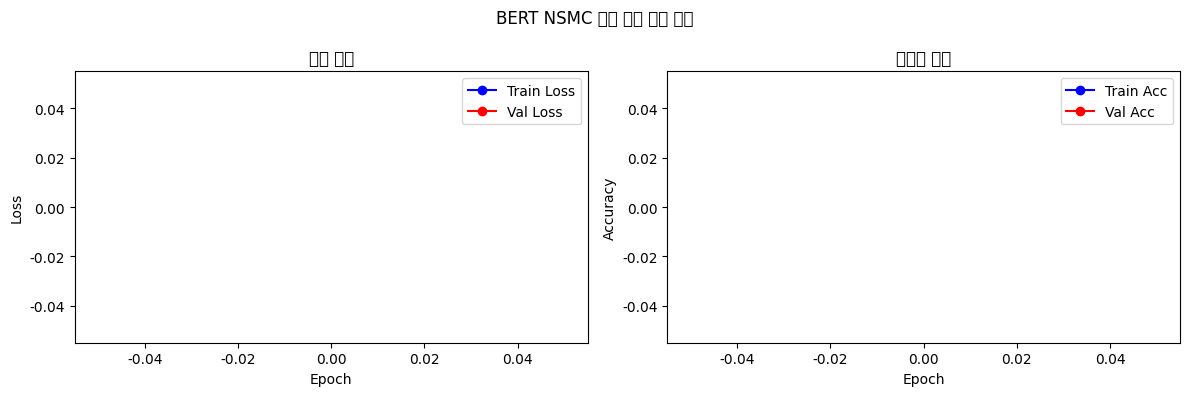

In [37]:
# 에포크 1부터 실제 학습한 에포크 수까지의 Range 생성
# Early Stopping으로 NUM_EPOCHS보다 적게 학습될 수 있으므로 history 길이 기준으로 생성
epochs = range(1, len(history['train_loss']) + 1)

# 서브 플롯 생성: 1행 2열, 전체 크기 (12, 4)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 손실 곡선 그리기
# b-o: 파란색 선과 원형 마커, r-o: 빨간색 선과 원형 마커
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('손실 곡선')
ax1.legend()

# 정확도 곡선 그리기
# b-o: 파란색 선과 원형 마커, r-o: 빨간색 선과 원형 마커
ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
ax2.plot(epochs, history['val_acc'], 'r-o', label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('정확도 곡선')
ax2.legend()

# 전체 제목과 레이아웃 조정 후 플롯 표시
plt.suptitle('BERT NSMC 감성 분석 학습 결과')
plt.tight_layout()
plt.show()

##### 예측 함수 정의

In [38]:
def predict(text, model, tokenizer, device):
    # 모델을 평가 모드로 설정
    # 드롭아웃 등 학습 시에만 활성화되는 레이어 비활성화
    model.eval()

    # 입력 텍스트를 토크나이저로 인코딩하여 input_ids, attention_mask, token_type_ids 생성
    encoding = tokenizer(
        text,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )

    # 토큰 ID, 어텐션 마스크, 토큰 타입 ID를 디바이스로 이동
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    token_type_ids = encoding['token_type_ids'].to(device)

    # 모델에 입력하여 출력 얻기 (그래디언트 계산 불필요)
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )

    # 출력에서 로짓을 소프트맥스하여 확률로 변환
    # - outputs.logits: 모델의 출력 로짓 텐서, (1, 2) 형태
    # - torch.softmax: 로짓을 확률로 변환하는 함수
    # - probs: 확률 텐서, (1, 2) 형태
    probs = torch.softmax(outputs.logits, dim=-1)

    # 확률이 가장 높은 클래스 예측
    pred = probs.argmax(dim=-1).item()

    # 예측된 클래스의 확률을 confidence로 저장
    confidence = probs[0][pred].item()

    # 예측된 클래스가 1이면 "긍정", 0이면 "부정"으로 라벨링
    label = "긍정" if pred == 1 else "부정"

    # 예측 라벨과 확신도 반환
    return label, confidence

##### 저장된 가중치로 로드 후 예측하기

In [39]:
# GPU(CUDA) 사용 가능 시 'cuda', 아니면 'cpu' 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 사용할 모델 이름
model_name = "klue/bert-base"

# 모델 구조 생성 (학습 때와 동일한 구조)
pred_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
)

# 토크나이저 로드
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 저장된 가중치 로드
# - torch.load()로 저장된 모델의 state_dict(가중치 딕셔너리)를 로드할 때,
# - 저장 당시 디바이스와 현재 디바이스가 다를 수 있으므로
# - map_location=device 옵션을 사용하여 현재 디바이스로 자동 변환
state_dict = torch.load(
    "runs/02/bert_nsmc_epoch_best.pt",
    map_location=device,
)

# 모델에 로드된 가중치 적용
pred_model.load_state_dict(state_dict)

# 모델을 예측에 사용할 디바이스로 이동
pred_model = pred_model.to(device)

# 샘플 1개로 예측
text = "관람내내 지루하지 않게 봤습니다."
label, confidence = predict(text, pred_model, tokenizer, device)
print(f"입력: {text}")
print(f"예측: {label} ({confidence:.2%})")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on you

입력: 관람내내 지루하지 않게 봤습니다.
예측: 긍정 (96.76%)
